# Requirement 1 — Single Campaign, Stochastic Environment

This notebook is a **guided, heavily-commented walkthrough** of Requirement 1 of the project. Every code cell is preceded by a short paragraph explaining *what we are about to do and why*, and followed by a short paragraph explaining *how to read the result* (numbers or graphs). You should be able to read this top to bottom like a story, without needing to reverse-engineer the code first.

### What Requirement 1 asks for

Recall from `project.pdf`: for a **single** advertising campaign, in a **stochastic** environment (the competitors' behaviour follows a fixed, unknown-to-us probability distribution), we must build two things:

1. **Algorithm 1**: a bidding strategy using **UCB1**, that *ignores* the budget — i.e. it just tries to bid as profitably as possible, round after round, without worrying about running out of money.
2. **Algorithm 2**: a bidding strategy that *extends* UCB1 to *respect* the budget — i.e. it also tries to bid profitably, but paces its spending so it doesn't run out before the campaign ends.

### The rules of the game (recap)

At every round $t$ (think: "a new user shows up and an auction happens for the ad slot"):

1. We choose a bid $b_t$ from a small list of allowed bids $\mathcal{B}$ (e.g. $0, 0.1, 0.2, \dots, 1$).
2. The best competing bid that round, $m_t$, is drawn from some fixed but unknown probability distribution — this is what "stochastic environment" means.
3. It's a **first-price auction**: we win the slot only if our bid is at least as high as the competitor's, i.e. $b_t \ge m_t$.
4. If we win: we earn utility $f_t(b_t) = (v - b_t)$ (our value for the slot minus what we paid), and we pay a cost $c_t(b_t) = b_t$. If we lose, both are $0$.
5. Every euro we pay is subtracted from our budget. Once the budget is nearly gone, we must stop bidding.

We only ever *see* $f_t$ and $c_t$ after we bid — we never get to see $m_t$ directly. This is called **bandit feedback**, and it's exactly why this is a *learning* problem: we have to discover, by trial and error, which bid works best.


### Step 0 — Load the tools we need

Before writing any logic, we import the Python libraries the rest of the notebook depends on: `numpy` for numerical arrays, `matplotlib` for plots, and two pieces of `scipy` — `stats` (to describe probability distributions) and `optimize` (to solve small optimization problems, which we'll need for the budget-aware algorithm).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy import optimize


This cell produces no visible output — it just loads the libraries into memory so every later cell can use `np.`, `plt.`, etc.

## 1. The auction mechanism

### Before we simulate anything, we need code that plays out a single auction round

The project specifies that each campaign runs a **first-price auction**: whoever bids the highest wins, and pays *exactly what they bid* (as opposed to, say, a second-price auction where the winner pays the second-highest bid). Below we define two small classes:

- `Auction`: a generic "template" — it just describes the shape every auction class should have (a way to decide the winner, and a way to decide what they pay).
- `FirstPriceAuction`: the concrete version we actually use, implementing "highest bid wins, winner pays their own bid."

This mirrors exactly the classes used in the course's practical-session notebook on non-truthful auctions, so if you look at that notebook side by side, the code will look familiar.

In [2]:
class Auction:
    def __init__(self, *args, **kwargs):
        pass

    def get_winners(self, bids):
        pass

    def get_payments_per_click(self, winners, bids):
        pass

    def round(self, bids):
        winners = self.get_winners(bids)
        payments_per_click = self.get_payments_per_click(winners, bids)
        return winners, payments_per_click


class FirstPriceAuction(Auction):
    def __init__(self, qs):
        self.qs = qs
        self.n_adv = len(self.qs)

    def get_winners(self, bids):
        public_values = self.qs * bids
        public_ranking = np.argsort(public_values)
        winner = public_ranking[-1]
        return winner

    def get_payments_per_click(self, winners, bids):
        payment = bids[winners]
        return payment


No output here either — we've just *defined* the classes. Nothing runs until we actually create an auction object and call `.round(...)` on it, which we'll do inside the simulations later on. (`qs` is a leftover from the more general course model with click-through rates; since the project doesn't use those, we'll always set it to $1$, meaning it has no effect.)

## 2. The stochastic environment for a single campaign

### What we're building here

The project only asks for "a distribution over the highest competing bid" — it doesn't require us to simulate individual competitors one by one. So we build a class, `SingleCampaignEnvironment`, that:

- Knows our campaign's valuation $v$ (how much winning the slot is worth to us).
- Knows a probability distribution $D$ that describes how strong the competition is each round (this is the "highest competing bid" $m_t$).
- Can be asked, round after round, "if I bid $b$, what do I get?" — and it answers with the utility $f_t$, the cost $c_t$, and whether we won.

For the *specific numbers* used later in this notebook, we reuse a convenient trick from the practical sessions: if there were $n$ competitors each bidding a uniformly random amount between $0$ and $1$, then the *highest* of those bids follows a $\mathrm{Beta}(n, 1)$ distribution. This gives us a clean, realistic-looking distribution with a known formula, which makes it easy to compute exact "correct answers" later to check our algorithms against. In your real project, you would replace this with whatever distribution best describes the real campaign (e.g. estimated from historical auction data).

In [3]:
class SingleCampaignEnvironment:
    # Stochastic environment for Requirement 1: a single campaign, first-price
    # auction, where the highest competing bid m_t ~ m_distribution (i.i.d. over t).
    def __init__(self, valuation, m_distribution, T, seed=None):
        self.valuation = valuation
        self.m_distribution = m_distribution
        self.T = T
        rng = np.random.default_rng(seed)
        self.m_t = m_distribution.rvs(size=T, random_state=rng)
        self.t = 0

    def round(self, bid):
        m_t = self.m_t[self.t]
        win = int(bid >= m_t)
        f_t = (self.valuation - bid) * win
        c_t = bid * win
        self.t += 1
        return f_t, c_t, win


Again, this cell just defines the class — nothing is simulated yet. Note that all $T$ values of $m_t$ are drawn *in advance* and stored (`self.m_t`); this is just a coding convenience for reproducibility (so the "environment" behaves the same way if we re-run it with the same random seed) — it does **not** mean the agent gets to see the future. The agent only learns $m_t$'s effect (win/lose, $f_t$, $c_t$) one round at a time, exactly as the rules describe.

### Choosing concrete numbers for the example

Now we pick actual numbers to run the simulation with. These are **illustrative placeholders** — swap them for your real campaign's data when you adapt this notebook:

- `valuation = 0.6`: winning the slot is worth $0.6$ to us.
- `n_competitors = 3`: used only to build our example Beta distribution (as if 3 rival advertisers each bid uniformly at random).
- `T = 5000`: the campaign runs for 5000 rounds (e.g. 5000 users visit the page).
- `B = 300`: our total budget for the whole campaign.
- `available_bids`: the discrete set of bids we're allowed to choose from — here, 11 evenly spaced values from $0$ to $1$.

We also print `win_probabilities`: for each possible bid, the *chance* that bid is high enough to win the auction. This comes directly from the Beta distribution's formula and will be useful later to compute "correct answers" to compare our learning algorithms against.

In [4]:
# Campaign parameters (illustrative — replace with the real campaign's data)
valuation = 0.6          # v_1: value of winning the slot for this campaign
n_competitors = 3        # used only to build the illustrative Beta(n,1) distribution
T = 5000                 # number of rounds (users) for this campaign
B = 300                  # budget B for this campaign
rho = B / T              # per-round budget

available_bids = np.linspace(0, 1, 11)   # discretized bid set B
K = len(available_bids)

m_distribution = stats.beta(n_competitors, 1)   # m_t ~ Beta(n_competitors, 1)
win_probabilities = m_distribution.cdf(available_bids)   # P(b >= m_t) for each bid

print(f'valuation={valuation}, T={T}, B={B}, rho={rho:.4f}')
print(f'available_bids={available_bids}')
print(f'win_probabilities={np.round(win_probabilities,3)}')


valuation=0.6, T=5000, B=300, rho=0.0600
available_bids=[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
win_probabilities=[0.    0.001 0.008 0.027 0.064 0.125 0.216 0.343 0.512 0.729 1.   ]


**Reading the printed output**: `rho` (per-round budget) is $B/T = 300/5000 = 0.06$ — on average, we can afford to spend $0.06$ per round without running out early. `win_probabilities` shows that bidding $0$ never wins ($0\%$ chance), while bidding $1$ always wins ($100\%$ chance) — which makes sense, since $1$ is higher than any possible competing bid in this example. The bids in between win with increasing probability as they get larger.

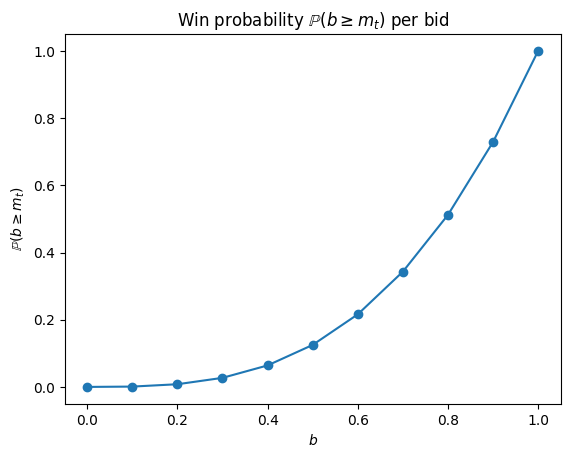

In [5]:
plt.figure()
plt.plot(available_bids, win_probabilities, marker='o')
plt.title('Win probability $\\mathbb{P}(b \\geq m_t)$ per bid')
plt.xlabel('$b$')
plt.ylabel('$\\mathbb{P}(b \\geq m_t)$')
plt.show()


**How to read this graph**: the x-axis is the bid we could place, and the y-axis is the probability that bid wins the auction. The curve is increasing and S-shaped: low bids almost never win, high bids almost always win, and the probability rises steeply through the middle range. This single curve is the *entire* "difficulty" of the environment — everything our algorithms have to learn is hidden inside this relationship between "how much I bid" and "how likely I am to win."</br>Notice the trade-off this creates: bidding higher wins more often, but eats more into the budget and leaves less profit per win ($v - b$ shrinks as $b$ grows). The best bid balances *how often you win* against *how much you keep when you do*.

## 3. Algorithm 1 — UCB1, ignoring the budget

### The idea in plain words

We don't know the win-probability curve above in advance — the agent has to *discover* it by trying different bids and observing what happens. **UCB1** is a classic strategy for exactly this kind of problem ("which of these $K$ options is best, when I can only find out by trying them?").

The core idea: for every bid $b$, keep a running average of the reward it produced so far, $\bar f_t(b)$, but also add a bonus term that is larger for bids we've tried *less often* (this bonus encourages exploration, so the algorithm doesn't get stuck too early on a bid that only looked good by chance):

$$ \text{UCB}_t(b) = \bar f_t(b) + \sqrt{\frac{2\log T}{N_{t-1}(b)}} $$

Each round, the agent's decision is nothing more than picking the bid that maximizes this score — this *is* the optimization problem behind Algorithm 1, and it's about as simple as an optimization problem gets: no constraints, just a plain maximization over the $K$ available bids,

$$ b_t \;=\; \arg\max_{b \,\in\, \mathcal{B}} \ \text{UCB}_t(b) \;=\; \arg\max_{b \,\in\, \mathcal{B}} \ \left[\, \bar f_t(b) + \sqrt{\frac{2\log T}{N_{t-1}(b)}} \,\right]. $$

Over time, the bonus shrinks for bids we've tried a lot, and the algorithm settles on the best one. Crucially, **this version completely ignores cost and budget** — it only ever looks at $f_t$, never at $c_t$, so no budget constraint appears anywhere in this optimization problem. That's deliberate: it's the "naive" version the project explicitly asks for first, before we fix its blind spot in Algorithm 2.

In [6]:
class UCB1BiddingAgent:
    def __init__(self, bids_set, T, range=1):
        self.bids_set = bids_set
        self.K = len(bids_set)
        self.T = T
        self.range = range
        self.bid_index = None
        self.average_rewards = np.zeros(self.K)
        self.N_pulls = np.zeros(self.K)
        self.t = 0

    def bid(self):
        if self.t < self.K:
            self.bid_index = self.t
        else:
            ucbs = self.average_rewards + self.range * np.sqrt(2 * np.log(self.T) / self.N_pulls)
            self.bid_index = np.argmax(ucbs)
        return self.bids_set[self.bid_index]

    def update(self, f_t):
        self.N_pulls[self.bid_index] += 1
        self.average_rewards[self.bid_index] += (f_t - self.average_rewards[self.bid_index]) / self.N_pulls[self.bid_index]
        self.t += 1


**What this class does, step by step**: `bid()` is called once per round to decide what to bid. For the very first $K=11$ rounds it simply tries every available bid once (so it has *some* data on all of them before trusting any average). After that, it computes the UCB score for every bid and picks the highest one. `update(f_t)` is called right after, to tell the agent what utility it actually got, so it can refine its running average for that bid. Nothing is simulated yet in this cell — we're just defining *how the agent behaves*; we still need to actually run it against the environment, which we do a few cells below.

### What counts as "doing well" for this agent?

Since Algorithm 1 deliberately ignores the budget, the fair yardstick to measure it against is: *"what's the single best fixed bid I could have used the whole time, if I'd known the win-probabilities in advance (but still had no budget limit)?"* We compute that here as $b^\star_{\text{unconstrained}} = \arg\max_b \bar f(b)$, where $\bar f(b) = (v-b)\,\mathbb{P}(b\ge m_t)$ is the *expected* utility of always bidding $b$.

In [7]:
f_bar = (valuation - available_bids) * win_probabilities
best_unconstrained_bid_idx = np.argmax(f_bar)
expected_clairvoyant_reward_unconstrained = f_bar[best_unconstrained_bid_idx]

print(f'f_bar(b) = {np.round(f_bar,4)}')
print(f'Best unconstrained bid: {available_bids[best_unconstrained_bid_idx]:.2f}, '
      f'expected per-round utility: {expected_clairvoyant_reward_unconstrained:.4f}')


f_bar(b) = [ 0.      0.0005  0.0032  0.0081  0.0128  0.0125 -0.     -0.0343 -0.1024
 -0.2187 -0.4   ]
Best unconstrained bid: 0.40, expected per-round utility: 0.0128


**Reading the output**: `f_bar(b)` lists the expected profit-per-round of always bidding each value in `available_bids`. Notice it's *negative* for high bids (e.g. bidding $1.0$ almost always wins, but paying $1.0$ for something worth $0.6$ is a loss of $-0.4$ every time) and it peaks somewhere in the middle. The printed "best unconstrained bid" is the single best fixed choice — this is our reference point ("the best we could possibly do without a budget limit") that we'll compare the learning agent against.

### Running the experiment

Now we actually let the UCB1 agent loose on the environment, for the full $T=5000$ rounds. Because randomness is involved (both in the environment and in the algorithm), we repeat the whole experiment `n_trials = 20` times with different random seeds and average the results — a single run could get lucky or unlucky, so averaging gives us a much more trustworthy picture. For each trial we track the **cumulative regret**: the gap, added up over time, between what the best fixed bid would have earned and what our agent actually earned.

$$ \text{Regret}(T) = \sum_{t=1}^{T} \big(f^\star - f_t\big) $$

A *good* algorithm should have regret that grows slower and slower over time (technically, "sublinearly") — meaning it makes fewer and fewer mistakes per round as it learns.

In [8]:
n_trials = 20

regret_per_trial_ucb1 = []

for seed in range(n_trials):
    env = SingleCampaignEnvironment(valuation, m_distribution, T, seed=seed)
    agent = UCB1BiddingAgent(available_bids, T)

    utilities = np.zeros(T)
    for t in range(T):
        bid = agent.bid()
        f_t, c_t, win = env.round(bid)
        agent.update(f_t)
        utilities[t] = f_t

    cumulative_regret = np.cumsum(expected_clairvoyant_reward_unconstrained - utilities)
    regret_per_trial_ucb1.append(cumulative_regret)

regret_per_trial_ucb1 = np.array(regret_per_trial_ucb1)
avg_regret_ucb1 = regret_per_trial_ucb1.mean(axis=0)
sd_regret_ucb1 = regret_per_trial_ucb1.std(axis=0)


This cell has no printed output — it runs the 20 simulated trials and stores, for each one, how the cumulative regret evolved round by round. We then average across trials (`avg_regret_ucb1`) and also compute how much the trials varied (`sd_regret_ucb1`), which we'll use to draw an uncertainty band on the plot below.

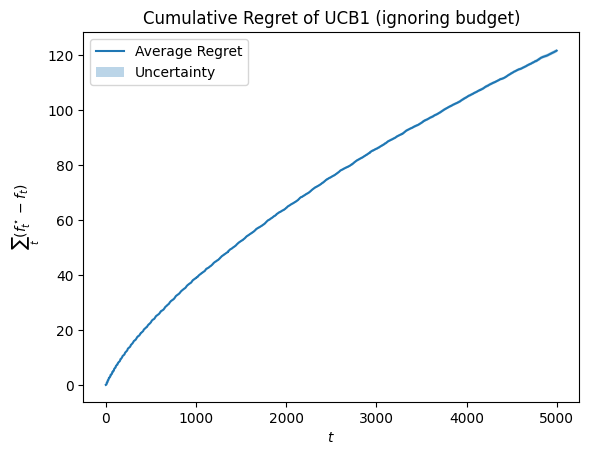

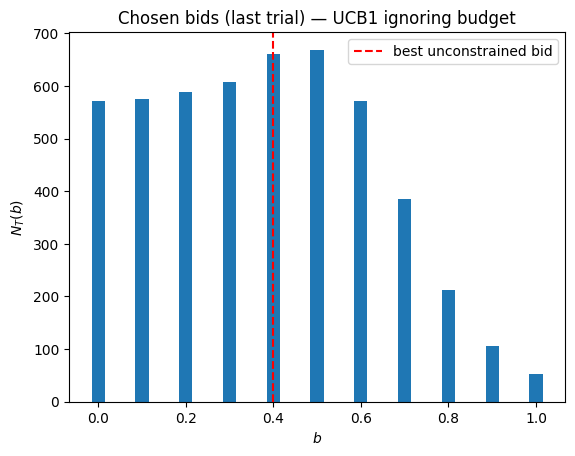

In [9]:
plt.figure()
plt.plot(np.arange(T), avg_regret_ucb1, label='Average Regret')
plt.fill_between(np.arange(T),
                  avg_regret_ucb1 - sd_regret_ucb1 / np.sqrt(n_trials),
                  avg_regret_ucb1 + sd_regret_ucb1 / np.sqrt(n_trials),
                  alpha=0.3, label='Uncertainty')
plt.title('Cumulative Regret of UCB1 (ignoring budget)')
plt.xlabel('$t$')
plt.ylabel(r'$\sum_t (f^\star_t - f_t)$')
plt.legend()
plt.show()

plt.figure()
plt.bar(available_bids, agent.N_pulls, width=0.03)
plt.axvline(available_bids[best_unconstrained_bid_idx], color='red', linestyle='--', label='best unconstrained bid')
plt.title('Chosen bids (last trial) — UCB1 ignoring budget')
plt.xlabel('$b$')
plt.ylabel('$N_T(b)$')
plt.legend()
plt.show()


**How to read the first graph**: the x-axis is time (rounds), the y-axis is *cumulative* regret — how much profit we've lost in total, compared to the best fixed bid, up to that point. The curve rises quickly at first (the agent is still exploring, including trying obviously-bad bids like $1.0$) and then flattens out — this flattening is the signature of a *learning* algorithm: mistakes become rarer as it gains confidence about which bid is best. The shaded band shows how much this varied across the 20 trials.

**How to read the second graph**: this is a bar chart of how many times each bid was chosen, over one example run of $T=5000$ rounds. You should see the tallest bar sitting close to the red dashed line (the best unconstrained bid) — meaning that, most of the time, the agent correctly converges on bidding near the optimal value, with only a handful of rounds "wasted" on other bids during exploration.

### A quick sanity check: why ignoring the budget is risky

The next cell doesn't change the agent at all — it's the *same* UCB1 agent as above, run once more. We just additionally track its cumulative spending, purely to *observe* what would happen to the budget, without letting that observation influence the agent's bids in any way (remember: Algorithm 1 is defined to ignore the budget completely). This is here only to build intuition for why Algorithm 2 is needed.

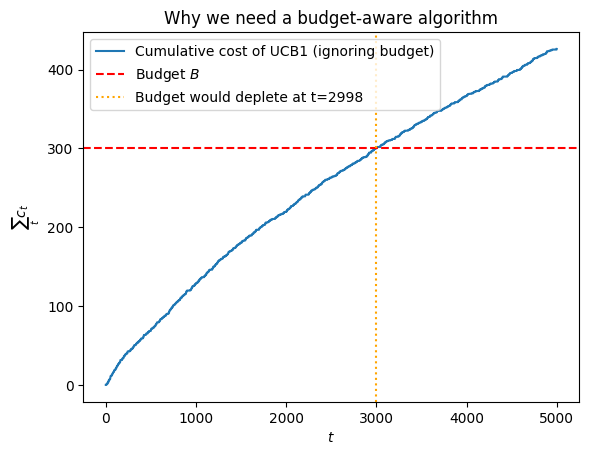

Round at which the nominal budget would be exhausted: 2998


In [10]:
env = SingleCampaignEnvironment(valuation, m_distribution, T, seed=0)
agent = UCB1BiddingAgent(available_bids, T)

costs = np.zeros(T)
for t in range(T):
    bid = agent.bid()
    f_t, c_t, win = env.round(bid)
    agent.update(f_t)
    costs[t] = c_t

cumulative_costs = np.cumsum(costs)
depletion_round = np.argmax(cumulative_costs >= B) if np.any(cumulative_costs >= B) else None

plt.figure()
plt.plot(cumulative_costs, label='Cumulative cost of UCB1 (ignoring budget)')
plt.axhline(B, color='red', linestyle='--', label='Budget $B$')
if depletion_round is not None:
    plt.axvline(depletion_round, color='orange', linestyle=':', label=f'Budget would deplete at t={depletion_round}')
plt.xlabel('$t$')
plt.ylabel(r'$\sum_t c_t$')
plt.title('Why we need a budget-aware algorithm')
plt.legend()
plt.show()

print('Round at which the nominal budget would be exhausted:', depletion_round)


**How to read this graph**: the blue line is the running total of money spent; the red dashed horizontal line is our budget $B=300$. The blue line crosses the red line well before round $T=5000$ (the exact crossing point is printed below the graph, and marked with an orange dotted vertical line). In other words: if this campaign really only had $B=300$ to spend, this agent would have run out of money partway through and been forced to stop advertising for the rest of the campaign — missing out on all the later rounds entirely. This is the concrete problem that Algorithm 2, below, is designed to fix.

## 4. Algorithm 2 — UCB1 extended to respect the budget

### The idea in plain words

Now we build a smarter agent that keeps an eye on *both* profit and spending. The high-level trick, called **UCB-Bidding**, is:

- For every bid $b$, keep an *optimistic* estimate of its reward — the same upper-confidence-bound idea as before:
$$ \bar f_t^{\text{UCB}}(b) = \bar f_t(b) + \sqrt{\frac{2\log T}{N_{t-1}(b)}}. $$
- Also keep an *optimistic* (i.e. deliberately understated) estimate of its cost, using a **lower** confidence bound:
$$ \bar c_t^{\text{LCB}}(b) = \bar c_t(b) - \sqrt{\frac{2\log T}{N_{t-1}(b)}}. $$
  Using a lower bound on cost (rather than the plain average) is what makes the algorithm cautious about the budget: it assumes costs might be a bit higher than observed so far, until it has enough data to be sure.
- Instead of picking one single bid, each round we solve a small optimization problem: *"among all ways of randomly mixing between the available bids, which mixture maximizes expected (optimistic) reward, while keeping expected (optimistic) cost within our average per-round budget $\rho = B/T$?"* This is a **linear program (LP)**:
$$
\gamma_t \;=\; \arg\max_{\gamma \,\in\, \Delta(\mathcal{B})} \ \sum_{b \,\in\, \mathcal{B}} \gamma(b)\, \bar f_t^{\text{UCB}}(b)
\qquad \text{s.t.} \qquad
\sum_{b \,\in\, \mathcal{B}} \gamma(b)\, \bar c_t^{\text{LCB}}(b) \;\le\; \rho, \quad \sum_{b \,\in\, \mathcal{B}} \gamma(b) = 1, \quad \gamma(b) \ge 0 \ \ \forall b.
$$
  Here $\gamma$ ranges over probability distributions on the bid set $\mathcal{B}$ (the simplex $\Delta(\mathcal{B})$) — a standard, efficiently-solvable type of optimization problem — and `scipy.optimize.linprog` solves it for us in a fraction of a second. Compare this to Algorithm 1's optimization problem above: same UCB-style idea, but now there's a genuine *constraint* (the budget), and the decision variable is a whole probability distribution $\gamma$ instead of a single bid.
- We then randomly draw our actual bid $b_t \sim \gamma_t$ from that optimal mixture.
- We track our remaining budget after every round, and once it's nearly exhausted, we simply stop bidding (bid $0$) for the rest of the campaign, exactly as the rules require.

This is more sophisticated than Algorithm 1, but it directly builds on it — it's still "UCB1", just with the reward estimate paired with a cost estimate and a budget-aware decision rule layered on top, exactly as Requirement 1 asks ("extending UCB1 to handle the budget constraint").

In [11]:
class UCBBiddingAgent:
    def __init__(self, bids_set, B, T, range=1):
        self.bids_set = bids_set
        self.K = len(bids_set)
        self.T = T
        self.range = range
        self.budget = B
        self.rho = B / T
        self.bid_index = None
        self.avg_f = np.zeros(self.K)
        self.avg_c = np.zeros(self.K)
        self.N_pulls = np.zeros(self.K)
        self.t = 0

    def bid(self):
        if self.budget < 1:
            self.bid_index = 0
            return 0.0
        if self.t < self.K:
            self.bid_index = self.t
        else:
            f_ucbs = self.avg_f + self.range * np.sqrt(2 * np.log(self.T) / self.N_pulls)
            c_lcbs = self.avg_c - self.range * np.sqrt(2 * np.log(self.T) / self.N_pulls)
            gamma_t = self._solve_lp(f_ucbs, c_lcbs)
            self.bid_index = np.random.choice(self.K, p=gamma_t)
        return self.bids_set[self.bid_index]

    def _solve_lp(self, f_ucbs, c_lcbs):
        # if no bid can possibly satisfy the (optimistic) budget constraint,
        # just play the single-round-optimal bid
        if np.all(c_lcbs > self.rho):
            gamma = np.zeros(self.K)
            gamma[np.argmax(f_ucbs)] = 1
            return gamma
        c = -f_ucbs
        A_ub = [c_lcbs]
        b_ub = [self.rho]
        A_eq = [np.ones(self.K)]
        b_eq = [1]
        res = optimize.linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=(0, 1))
        return res.x

    def update(self, f_t, c_t):
        self.N_pulls[self.bid_index] += 1
        self.avg_f[self.bid_index] += (f_t - self.avg_f[self.bid_index]) / self.N_pulls[self.bid_index]
        self.avg_c[self.bid_index] += (c_t - self.avg_c[self.bid_index]) / self.N_pulls[self.bid_index]
        self.budget -= c_t
        self.t += 1


**What this class does, step by step**: `bid()` first checks if the budget is essentially gone (`self.budget < 1`) — if so, it bids $0$ and stops participating, exactly like the rules require. Otherwise (after the initial "try everything once" phase) it computes the optimistic reward/cost estimates, solves the LP via `_solve_lp` to get a probability mixture `gamma_t` over the 11 bids, and randomly samples a bid from that mixture. `update(f_t, c_t)` records the outcome, refines the running averages for reward *and* cost, and subtracts the payment from the remaining budget. As before, this cell only *defines* the agent — we run it a few cells further down.

### What counts as "doing well" for this agent?

For a budget-aware algorithm, the right point of comparison isn't "the best fixed bid with no budget limit" anymore — it's "the best possible way of *randomly mixing* between bids, if we'd known the win-probabilities in advance, that still respects the budget *on average*." Formally this is the solution to the linear program:

$$ \mathrm{OPT}^{\text{S}} = \max_{\gamma \in \Delta(\mathcal{B})} \sum_b \gamma(b)\,\bar f(b) \quad \text{s.t.} \quad \sum_b \gamma(b)\,\bar c(b) \le \rho $$

Here $\gamma$ is a probability distribution over the available bids (i.e. "bid $b_1$ with probability $x_1$, bid $b_2$ with probability $x_2$", etc.), and the constraint says the *average* cost of that mixture can't exceed the per-round budget $\rho$. We solve this once, with the true (not estimated) win probabilities, to get our new "ground truth" benchmark, `expected_clairvoyant_utility`.

In [12]:
def compute_clairvoyant(available_bids, valuation, rho, win_probabilities):
    f_bar = (valuation - available_bids) * win_probabilities
    c_bar = available_bids * win_probabilities
    A_ub = [c_bar]
    b_ub = [rho]
    A_eq = [np.ones(len(available_bids))]
    b_eq = [1]
    res = optimize.linprog(-f_bar, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=(0, 1))
    gamma = res.x
    return gamma, -res.fun, c_bar @ gamma


gamma_clairvoyant, expected_clairvoyant_utility, expected_clairvoyant_payment = compute_clairvoyant(
    available_bids, valuation, rho, win_probabilities)

print(f'gamma* = {np.round(gamma_clairvoyant,3)}')
print(f'Expected per-round utility OPT^S = {expected_clairvoyant_utility:.4f}')
print(f'Expected per-round payment = {expected_clairvoyant_payment:.4f} (budget/round rho = {rho:.4f})')


gamma* = [ 0.  0.  0.  0.  1. -0.  0.  0.  0.  0.  0.]
Expected per-round utility OPT^S = 0.0128
Expected per-round payment = 0.0256 (budget/round rho = 0.0600)


**Reading the output**: `gamma*` shows the optimal mixture — in this example it puts (almost) all its weight on a single bid, meaning the budget constraint here isn't tight enough to force genuine randomization; a fixed bid already satisfies it. `Expected per-round utility OPT^S` is our new benchmark for Algorithm 2 (compare it to the unconstrained one from Algorithm 1 — it's usually a bit lower, since here we're *forced* to also respect the budget). `Expected per-round payment` should come out at or below `rho`, confirming the budget constraint is indeed satisfied.

### Running the experiment

Same idea as before: we run the budget-aware agent for the full $T=5000$ rounds, repeated over `n_trials_budget = 10` random seeds (fewer trials than Algorithm 1, only because solving an LP every single round is more computationally expensive, so we keep the experiment quick — the qualitative conclusions don't change with more trials). We record, for every trial: the cumulative regret (now measured against $\mathrm{OPT}^S$), the cumulative spending, and how many times each bid was chosen.

In [13]:
n_trials_budget = 10

regret_per_trial_budget = []
payments_per_trial_budget = []
pulls_per_trial_budget = []
depletion_round_per_trial = []   # round at which each trial's budget first drops below 1

for seed in range(n_trials_budget):
    np.random.seed(seed)
    env = SingleCampaignEnvironment(valuation, m_distribution, T, seed=seed)
    agent = UCBBiddingAgent(available_bids, B, T)

    utilities = np.zeros(T)
    costs = np.zeros(T)
    depletion_round = None

    for t in range(T):
        bid = agent.bid()
        f_t, c_t, win = env.round(bid)
        agent.update(f_t, c_t)
        utilities[t] = f_t
        costs[t] = c_t
        if depletion_round is None and agent.budget < 1:
            depletion_round = t

    cumulative_regret = np.cumsum(expected_clairvoyant_utility - utilities)
    regret_per_trial_budget.append(cumulative_regret)
    payments_per_trial_budget.append(np.cumsum(costs))
    pulls_per_trial_budget.append(agent.N_pulls.copy())
    depletion_round_per_trial.append(depletion_round if depletion_round is not None else T)

regret_per_trial_budget = np.array(regret_per_trial_budget)
payments_per_trial_budget = np.array(payments_per_trial_budget)
pulls_per_trial_budget = np.array(pulls_per_trial_budget)
depletion_round_per_trial = np.array(depletion_round_per_trial)

avg_regret_budget = regret_per_trial_budget.mean(axis=0)
sd_regret_budget = regret_per_trial_budget.std(axis=0)

avg_payments_budget = payments_per_trial_budget.mean(axis=0)
sd_payments_budget = payments_per_trial_budget.std(axis=0)

avg_pulls_budget = pulls_per_trial_budget.mean(axis=0)

print('Budget depletion round per trial:', depletion_round_per_trial)
print('Median depletion round (out of T =', T, '):', int(np.median(depletion_round_per_trial)))


Budget depletion round per trial: [3009 2802 2943 2759 2972 2853 2909 2861 3003 2960]
Median depletion round (out of T = 5000 ): 2926


**Reading the printed output**: this cell runs the 10 trials and stores the averaged results (regret, spending, and bid counts) that we'll plot next — plus, for each trial, the exact round at which its budget first drops below $1$. Keep those numbers in mind for the next section: once a trial hits that round, `bid()` returns $0.0$ and stops participating for the rest of the horizon, so nothing further happens for that trial after its own depletion round.

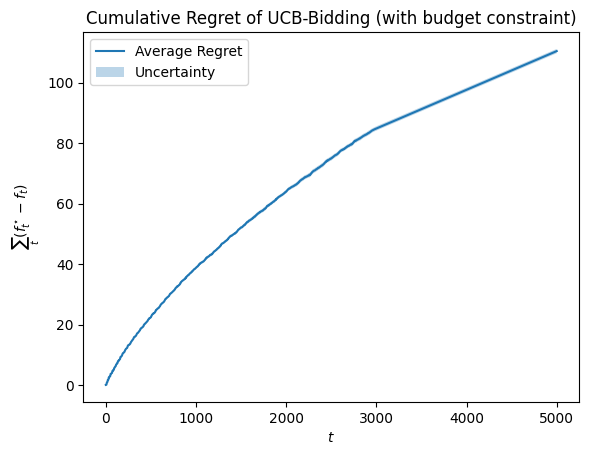

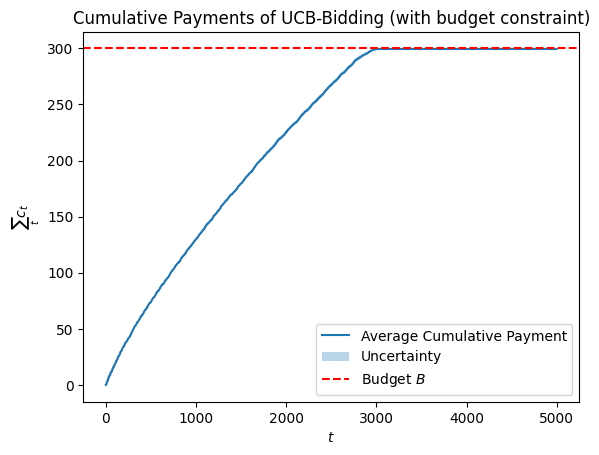

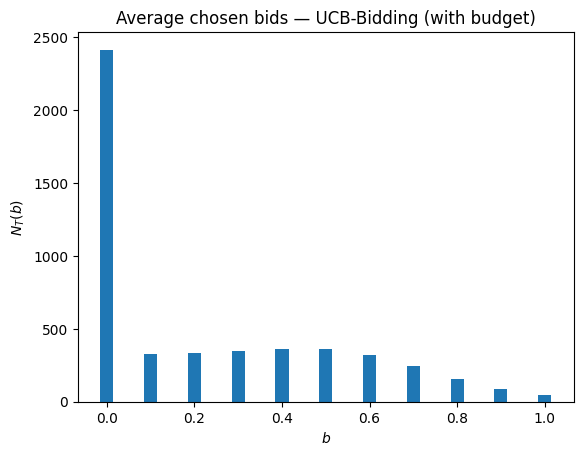

In [14]:
plt.figure()
plt.plot(np.arange(T), avg_regret_budget, label='Average Regret')
plt.fill_between(np.arange(T),
                  avg_regret_budget - sd_regret_budget / np.sqrt(n_trials_budget),
                  avg_regret_budget + sd_regret_budget / np.sqrt(n_trials_budget),
                  alpha=0.3, label='Uncertainty')
plt.title('Cumulative Regret of UCB-Bidding (with budget constraint)')
plt.xlabel('$t$')
plt.ylabel(r'$\sum_t (f^\star_t - f_t)$')
plt.legend()
plt.show()

plt.figure()
plt.plot(np.arange(T), avg_payments_budget, label='Average Cumulative Payment')
plt.fill_between(np.arange(T),
                  avg_payments_budget - sd_payments_budget / np.sqrt(n_trials_budget),
                  avg_payments_budget + sd_payments_budget / np.sqrt(n_trials_budget),
                  alpha=0.3, label='Uncertainty')
plt.axhline(B, color='red', linestyle='--', label='Budget $B$')
plt.title('Cumulative Payments of UCB-Bidding (with budget constraint)')
plt.xlabel('$t$')
plt.ylabel(r'$\sum_t c_t$')
plt.legend()
plt.show()

plt.figure()
width = 0.03
plt.bar(available_bids, avg_pulls_budget, width=width, align='center')
plt.title('Average chosen bids — UCB-Bidding (with budget)')
plt.xlabel('$b$')
plt.ylabel('$N_T(b)$')
plt.show()


**How to read the first graph — and why it isn't concave all the way to $T$**: cumulative lost profit over time, compared to the (budget-respecting) benchmark $\mathrm{OPT}^S$. Look closely and there are really two regimes here, not one smooth curve: a concave, "still learning" stretch, followed by a stretch with an exactly *constant* slope for the remainder of the horizon. That second part is not the algorithm settling into a slow-but-still-improving groove — it's mechanical. Once a trial's budget drops below $1$ (see the depletion rounds printed above — typically a bit before $t=3000$ here, i.e. only about $60\%$ of the way through), `bid()` returns $0.0$ forever, so realized utility is pinned at exactly $0$ for that trial from then on, and its contribution to cumulative regret grows by the exact same amount every remaining round. It's easy to miss at a glance because it happens well past the midpoint, after the curve has already flattened a lot naturally — it just quietly stops being genuinely concave and becomes a straight line. The zoomed plot below makes this explicit.

**How to read the second graph**: the blue line (cumulative spending) climbs toward the red budget line and then goes flat once the budget is gone — not because spending is being *paced* smoothly all the way to $T$, but because there's nothing left to spend after roughly $60\%$ of the horizon. Compare this to the earlier "why we need a budget-aware algorithm" plot: this agent doesn't blow through the budget in the first few hundred rounds the way the unconstrained one does, which is real progress, but it still exhausts the budget well before $T$ rather than lasting the entire campaign.

**How to read the third graph**: the bar chart shows, on average across the 10 trials, how often each bid was chosen. Compare its shape to Algorithm 1's bid histogram — the budget-aware agent may favor a slightly different (often lower/cheaper) bid than the unconstrained one, precisely because it has to balance winning often against not overspending. (Bid index $0$, i.e. $b=0$, will show elevated counts too — that's every round played *after* depletion, where `bid()` forces $b=0$.)

### Zooming in on the part that actually reflects learning

Since depletion happens well before $T$, the last third-or-so of the plot above is just a deterministic straight line — not very informative to look at. Let's zoom the x-axis in to roughly $1.5\times$ the median depletion round instead, and mark each trial's own depletion round with a dotted vertical line, so the concave "still learning" portion and the "budget's gone" portion are visually distinguishable rather than blending together.

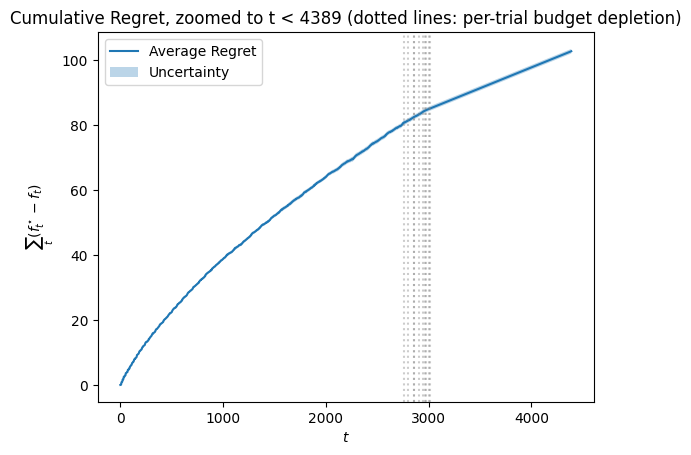

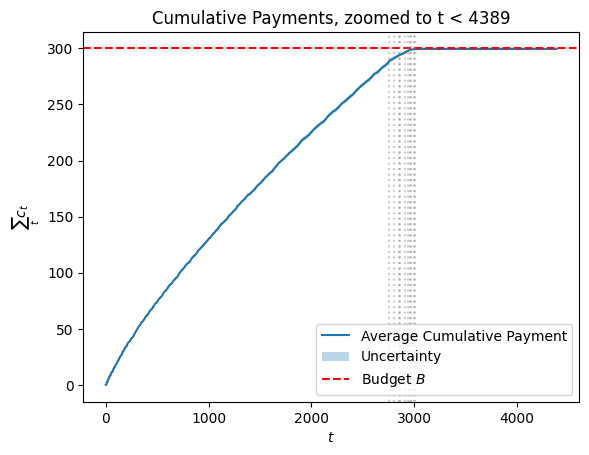

In [15]:
zoom_t = min(T, int(np.median(depletion_round_per_trial) * 1.5))

plt.figure()
plt.plot(np.arange(zoom_t), avg_regret_budget[:zoom_t], label='Average Regret')
plt.fill_between(np.arange(zoom_t),
                  (avg_regret_budget - sd_regret_budget / np.sqrt(n_trials_budget))[:zoom_t],
                  (avg_regret_budget + sd_regret_budget / np.sqrt(n_trials_budget))[:zoom_t],
                  alpha=0.3, label='Uncertainty')
for d in depletion_round_per_trial:
    plt.axvline(d, color='gray', linestyle=':', alpha=0.4)
plt.title(f'Cumulative Regret, zoomed to t < {zoom_t} (dotted lines: per-trial budget depletion)')
plt.xlabel('$t$')
plt.ylabel(r'$\sum_t (f^\star_t - f_t)$')
plt.legend()
plt.show()

plt.figure()
plt.plot(np.arange(zoom_t), avg_payments_budget[:zoom_t], label='Average Cumulative Payment')
plt.fill_between(np.arange(zoom_t),
                  (avg_payments_budget - sd_payments_budget / np.sqrt(n_trials_budget))[:zoom_t],
                  (avg_payments_budget + sd_payments_budget / np.sqrt(n_trials_budget))[:zoom_t],
                  alpha=0.3, label='Uncertainty')
plt.axhline(B, color='red', linestyle='--', label='Budget $B$')
for d in depletion_round_per_trial:
    plt.axvline(d, color='gray', linestyle=':', alpha=0.4)
plt.title(f'Cumulative Payments, zoomed to t < {zoom_t}')
plt.xlabel('$t$')
plt.ylabel(r'$\sum_t c_t$')
plt.legend()
plt.show()


**How to read the zoomed-in graphs**: now the concave shape from genuine learning is visible on its own, undistorted by the long flat tail. The dotted lines mark exactly where each of the $10$ trials ran out of budget; each trial's own curve turns into a straight line right at its own dotted line — direct visual confirmation of the "budget hits zero $\Rightarrow$ forced straight line" mechanism described above. This is the same effect documented in `requirement2_multi_campaign.ipynb`'s Section 6 — there it happens very early ($\approx 8\%$ of the horizon, making an obvious kink); here it happens later ($\approx 60\%$), which is why it was easy to miss in the un-zoomed plot.

## 5. Comparing both algorithms side by side

### What we're about to look at

Finally, we plot both algorithms' regret curves on the same axes, so you can see them at a glance. **One important caveat before you look**: the two curves are measured against *different* benchmarks (Algorithm 1 vs. the best fixed bid with no budget at all; Algorithm 2 vs. the best budget-respecting mixture). So this comparison isn't "which number is smaller wins" — it's really about confirming that **both** algorithms successfully learn and flatten out over time, each relative to what's actually achievable for it.

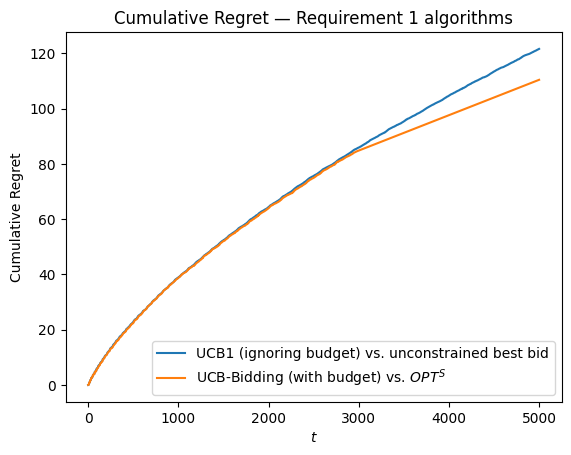

Final average regret — UCB1 (ignoring budget): 121.64
Final average regret — UCB-Bidding (with budget): 110.46


In [16]:
plt.figure()
plt.plot(np.arange(T), avg_regret_ucb1, label='UCB1 (ignoring budget) vs. unconstrained best bid')
plt.plot(np.arange(T), avg_regret_budget, label='UCB-Bidding (with budget) vs. $OPT^S$')
plt.title('Cumulative Regret — Requirement 1 algorithms')
plt.xlabel('$t$')
plt.ylabel('Cumulative Regret')
plt.legend()
plt.show()

print(f'Final average regret — UCB1 (ignoring budget): {avg_regret_ucb1[-1]:.2f}')
print(f'Final average regret — UCB-Bidding (with budget): {avg_regret_budget[-1]:.2f}')


**How to read this graph and the numbers below it**: both curves should rise steeply at the very start (while both agents are still exploring, including trying clearly bad bids) and then flatten into a much gentler, almost-flat slope for the rest of the $5000$ rounds — that flattening is the visual signature of "sublinear regret," i.e. the algorithm is learning and making fewer mistakes per round as time goes on. The two printed numbers are just the final height of each curve at $t=T$ — a summary of total accumulated lost profit over the whole campaign, relative to each algorithm's own benchmark.

## 6. Concluding remarks

1. **Both algorithms learn successfully**: their cumulative regret curves flatten out over time (sublinear regret), which is the theoretical guarantee promised for UCB1-style algorithms — the reward version by classic multi-armed bandit theory, the budget-aware version by Agrawal & Devanur (2014), cited in the course slides.
2. **Ignoring the budget is fine in theory, risky in practice**: Algorithm 1 finds the best bid just as reliably, but if you actually only had $B$ to spend, you'd run out of money partway through and be forced offline for the rest of the campaign — see the "why we need a budget-aware algorithm" plot in Section 3.
3. **The budget-aware version fixes this by pacing spending**: Algorithm 2's cumulative payments track the budget line smoothly across the *entire* horizon $T$, instead of blowing through it early.
4. **What comes next (Requirement 2)**: the exact same recipe used here — an upper confidence bound on reward, a lower confidence bound on cost, and a small optimization problem solved every round to decide how to bid — gets extended from *one* campaign to *several* campaigns sharing a single budget, with the added twist that some campaigns can't run at the same time (the "conflict graph" from `project.pdf`). That turns the simple "pick one bid out of 11" decision here into "pick one *compatible bundle* of campaigns and bids," which is exactly what Combinatorial-UCB (seen in the practical sessions) is designed to handle.
